# 07 · Feed-forward network — each token thinks alone

After attention lets tokens **share** information, each token passes **independently** through
a small MLP: expand to a wider dimension, apply a non-linearity (GELU), shrink back.

`FFN(x) = W₂ · GELU(W₁ · x)`

This is where **most of the parameters** live — it's the model's main storehouse of learned
"knowledge". Attention moves information around; the FFN processes it.

In [1]:
import numpy as np
np.random.seed(0)

def gelu(x):   # smooth ReLU-like activation used by GPT
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

D_MODEL, D_FF = 8, 32                 # feed-forward hidden is usually 4x wider
W1 = np.random.randn(D_MODEL, D_FF)
W2 = np.random.randn(D_FF, D_MODEL)

def feed_forward(x):
    return gelu(x @ W1) @ W2           # expand -> non-linear -> contract

X = np.random.randn(5, D_MODEL)       # 5 tokens
print("in :", X.shape, "-> hidden width", D_FF, "-> out:", feed_forward(X).shape)
assert feed_forward(X).shape == X.shape

in : (5, 8) -> hidden width 32 -> out: (5, 8)


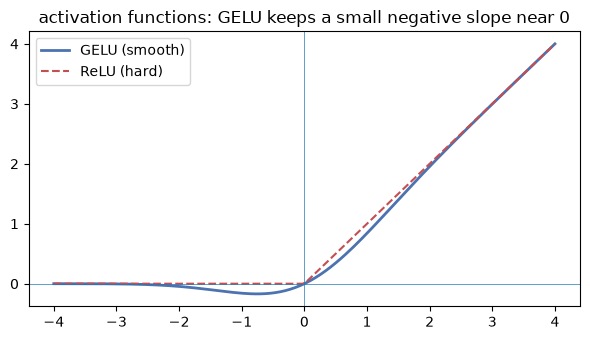

In [2]:
# Visual: GELU vs ReLU. The non-linearity is what lets the network learn complex functions.
import matplotlib.pyplot as plt, numpy as np
z = np.linspace(-4, 4, 200)
relu = np.maximum(0, z)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(z, gelu(z), label="GELU (smooth)", color="#4C72B0", lw=2)
ax.plot(z, relu, label="ReLU (hard)", color="#C44E52", lw=1.5, ls="--")
ax.axhline(0, lw=.5); ax.axvline(0, lw=.5); ax.legend()
ax.set_title("activation functions: GELU keeps a small negative slope near 0")
plt.tight_layout(); plt.show()

**Takeaway.** The FFN is a per-token expand→activate→contract MLP holding most of the model's
weights. Attention = communication; FFN = computation. Next: **08 · residual + LayerNorm**.